# Customer Churn Prediction for Credit Card Customers


**Dataset:** [Kaggle — Credit Card Customers (`BankChurners.csv`)](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)
sourced from a bank's internal customer database (~10,000 customers, 20+ attributes).



## 1.

### What is Customer Churn?

**Churn** (a.k.a. *attrition*) occurs when a customer stops using a company's product or service —
in this case, when a credit card holder closes their account or becomes inactive. For a card issuer,
a churned customer represents lost interest income, lost interchange fee revenue, and a lost
cross-sell opportunity for other financial products (loans, savings, investment accounts).

### Why Churn Prediction Matters

- **Acquisition is expensive.** It typically costs 5–7x more to acquire a new customer than to retain
  an existing one.
- **Churn is a leading indicator, not a lagging one.** By the time a customer closes their account,
  it is too late to intervene. A predictive model lets the business act *before* the customer leaves.
- **Not all customers are equal.** High-limit, high-spend customers who churn cause disproportionately
  larger revenue loss than low-engagement customers. Prediction lets retention teams prioritize effort.

### Business Impact

If the business can identify the ~16% of customers most likely to churn *before* they do, retention
teams can deploy targeted interventions (loyalty offers, fee waivers, relationship-manager outreach)
at a fraction of the cost of blanket retention campaigns aimed at the entire customer base.

### Project Goals

1. Understand the demographic, behavioral, and transactional drivers of churn.
2. Build and compare multiple classification models to predict churn risk.
3. Use model explainability (SHAP) to translate model output into **business-understandable drivers**.
4. Translate findings into **actionable retention strategies**.




- **numpy / pandas** — data manipulation
- **matplotlib / seaborn** — visualization
- **scikit-learn** — preprocessing, modeling, evaluation
- **xgboost** — gradient-boosted tree model
- **shap** — model explainability


We also set global plotting styles and a fixed random seed up front so that every result in this
notebook is **reproducible**.


In [ ]:
# --- Core libraries ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing & modeling ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# --- Gradient boosting ---
from xgboost import XGBClassifier

# --- Explainability ---
import shap

# --- Housekeeping ---
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot styling — clean, professional, consistent across the notebook
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

print("Libraries imported successfully.")
print(f"Random seed set to {RANDOM_STATE} for reproducibility.")


Libraries imported successfully.
Random seed set to 42 for reproducibility.


In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d sakshigoyal7/credit-card-customers -p data --unzip

Dataset URL: https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers
License(s): CC0-1.0
100% 379k/379k [00:00<00:00, 126MB/s]



In [ ]:
# KGAT_ea00832d111f7a3e9e97f6a67325a04a
import os

DATASET_MODE = "auto"  # "auto" | "bankchurners" | "telco"

CANDIDATE_PATHS_BANK = [
    "BankChurners.csv", "data/BankChurners.csv",
    "/content/BankChurners.csv", "/content/data/BankChurners.csv",
]
CANDIDATE_PATHS_TELCO = [
    "WA_Fn-UseC_-Telco-Customer-Churn.csv", "data/WA_Fn-UseC_-Telco-Customer-Churn.csv",
    "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv",
]

def find_first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

bank_path = find_first_existing(CANDIDATE_PATHS_BANK)
telco_path = find_first_existing(CANDIDATE_PATHS_TELCO)

if DATASET_MODE == "bankchurners" or (DATASET_MODE == "auto" and bank_path):
    df = pd.read_csv(bank_path)
    DATASET_USED = "BankChurners (Credit Card Customers)"
    TARGET_COL_RAW = "Attrition_Flag"
    POSITIVE_CLASS = "Attrited Customer"   # the "churn = 1" label in raw data
elif DATASET_MODE == "telco" or (DATASET_MODE == "auto" and telco_path):
    df = pd.read_csv(telco_path)
    DATASET_USED = "IBM Telco Customer Churn (fallback)"
    TARGET_COL_RAW = "Churn"
    POSITIVE_CLASS = "Yes"
else:
    raise FileNotFoundError(
        "Neither BankChurners.csv nor the Telco churn CSV was found.\n"
        "Please upload BankChurners.csv (see markdown above) and re-run this cell."
    )

print(f"Dataset loaded: {DATASET_USED}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")


Dataset loaded: BankChurners (Credit Card Customers)
Shape: 10127 rows x 23 columns


In [ ]:
# --- Basic structural overview ---
print("=" * 60)
print("SHAPE")
print("=" * 60)
print(df.shape)

print("\n" + "=" * 60)
print("HEAD")
print("=" * 60)
display(df.head())


SHAPE
(10127, 23)

HEAD


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [ ]:
print("=" * 60)
print("INFO")
print("=" * 60)
df.info()


INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                      

In [ ]:
print("=" * 60)
print("DESCRIBE (numerical features)")
print("=" * 60)
display(df.describe().T)


DESCRIBE (numerical features)


,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,7.080821e+08,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,2.600000e+01,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,1.300000e+01,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1.438300e+03,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.000000e+00,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.000000e+00,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


### Dataset Summary

`BankChurners.csv` contains **~10,127 credit card customers** described by **20+ attributes**,
spanning:

- **Demographics:** age, gender, dependent count, education level, marital status, income category
- **Relationship attributes:** months as a customer, number of products held, months inactive in the
  last 12 months, number of contacts with the bank in the last 12 months
- **Card & usage attributes:** card category, credit limit, revolving balance, average open-to-buy,
  transaction amount / count changes, total transaction amount / count, average utilization ratio
- **Target:** `Attrition_Flag` — `Existing Customer` vs. `Attrited Customer`

The dataset also ships with two Naive-Bayes classifier output columns (columns 21–22, prefixed
`Naive_Bayes_Classifier_...`) that the dataset author explicitly recommends dropping — they leak
information from a separate model and are **not legitimate input features**. We remove these in the
next section.


## 4. Data Cleaning

We perform the following cleaning steps, **explaining the reasoning behind each one**:

1. **Drop leakage / non-feature columns** — the two `Naive_Bayes_Classifier_...` columns are outputs
   of an unrelated model and `CLIENTNUM` is a unique customer ID with no predictive value (and using
   it would let a model "memorize" rows rather than generalize).
2. **Check and remove duplicates** — duplicate rows would let the same customer bias the model twice.
3. **Handle missing values** — verify whether nulls exist and decide row-drop vs. imputation based on
   the proportion missing.
4. **Fix datatypes** — ensure numeric columns are numeric and categorical columns are treated as
   categories, not free text.
5. **Standardize the target** — recode the target into a clean binary `Churn` column (`1` = churned).
6. **Rename columns** — convert to consistent, readable snake_case naming for downstream code clarity.


In [ ]:
def clean_credit_card_data(raw_df: pd.DataFrame, target_col_raw: str, positive_class: str) -> pd.DataFrame:
    """
    Clean the raw churn dataset.

    Steps:
        1. Drop leakage / identifier columns (Naive Bayes outputs, CLIENTNUM).
        2. Drop exact duplicate rows.
        3. Report and handle missing values.
        4. Cast datatypes appropriately.
        5. Create a clean binary target column `Churn`.
        6. Standardize column names to snake_case.

    Returns a cleaned copy of the dataframe; does not mutate the input.
    """
    data = raw_df.copy()

    # 1. Drop leakage / identifier columns (only drop what exists — keeps function dataset-agnostic)
    cols_to_drop = [c for c in data.columns if "Naive_Bayes_Classifier" in c]
    cols_to_drop += [c for c in ["CLIENTNUM", "customerID"] if c in data.columns]
    data = data.drop(columns=cols_to_drop, errors="ignore")
    print(f"Dropped {len(cols_to_drop)} non-feature columns: {cols_to_drop}")

    # 2. Duplicates
    n_dupes = data.duplicated().sum()
    data = data.drop_duplicates()
    print(f"Removed {n_dupes} duplicate rows.")

    # 3. Missing values
    missing = data.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print("Missing values found:")
        print(missing)
        # For this dataset, missingness (if any) is minimal — impute numeric with median,
        # categorical with mode, to avoid discarding customer records.
        for col in data.columns:
            if data[col].isnull().sum() > 0:
                if pd.api.types.is_numeric_dtype(data[col]):
                    data[col] = data[col].fillna(data[col].median())
                else:
                    data[col] = data[col].fillna(data[col].mode()[0])
    else:
        print("No missing values found.")

    # Some churn datasets encode unknowns as the string "Unknown" rather than NaN.
    # We keep "Unknown" as its own category (it can itself be predictive — customers who
    # don't disclose income/education may behave differently) rather than dropping those rows.
    unknown_counts = (data == "Unknown").sum()
    unknown_counts = unknown_counts[unknown_counts > 0]
    if len(unknown_counts) > 0:
        print("\nColumns containing an explicit 'Unknown' category (kept as-is):")
        print(unknown_counts)

    # 4. Compute the binary target before renaming columns, then drop the raw target column
    churn_series = (data[target_col_raw] == positive_class).astype(int)
    data = data.drop(columns=[target_col_raw])

    # 5. Standardize feature column names to snake_case for readability
    data.columns = (
        data.columns
        .str.strip()
        .str.replace(r"[^0-9a-zA-Z]+", "_", regex=True)
        .str.lower()
    )

    # Re-attach the target using a fixed, predictable name (kept capitalized so it reads
    # clearly downstream as "the label", distinct from the snake_case feature columns)
    data["Churn"] = churn_series.values

    return data


df_clean = clean_credit_card_data(df, TARGET_COL_RAW, POSITIVE_CLASS)

print(f"\nCleaned shape: {df_clean.shape}")
display(df_clean.head())


Dropped 3 non-feature columns: ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2', 'CLIENTNUM']
Removed 0 duplicate rows.
No missing values found.

Columns containing an explicit 'Unknown' category (kept as-is):
Education_Level    1519
Marital_Status      749
Income_Category    1112
dtype: int64

Cleaned shape: (10127, 20)


,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,Churn
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


In [ ]:
# Sanity check: confirm datatypes are sensible post-cleaning
df_clean.dtypes.value_counts()


**Why we kept `Unknown` as a category rather than dropping or imputing it:** in customer data,
*non-disclosure itself can be a behavioral signal* (e.g., customers who don't share income info may
be less engaged with the bank). Dropping ~10–15% of rows to remove "Unknown" values would needlessly
shrink the training set and could bias the model toward more disclosure-willing customers.


## 5. Exploratory Data Analysis (EDA)

Our goal in this section is not just to visualize the data, but to **build a business narrative**:
which customer segments churn more, and what does that imply operationally?

We'll identify the relevant column names dynamically so this section is robust to either dataset.


In [ ]:
# Resolve column names that may differ slightly by naming convention, so EDA code is robust
def resolve_col(df_, *candidates):
    for c in candidates:
        if c in df_.columns:
            return c
    return None

col_gender      = resolve_col(df_clean, "gender")
col_age         = resolve_col(df_clean, "customer_age", "age")
col_income      = resolve_col(df_clean, "income_category")
col_card        = resolve_col(df_clean, "card_category", "contract")
col_months_book = resolve_col(df_clean, "months_on_book", "tenure")
col_trans_ct    = resolve_col(df_clean, "total_trans_ct")
col_trans_amt   = resolve_col(df_clean, "total_trans_amt", "totalcharges")
col_credit_lim  = resolve_col(df_clean, "credit_limit", "monthlycharges")

print("Resolved columns:")
for name in ["col_gender","col_age","col_income","col_card","col_months_book",
             "col_trans_ct","col_trans_amt","col_credit_lim"]:
    print(f"  {name}: {eval(name)}")


Resolved columns:
  col_gender: gender
  col_age: customer_age
  col_income: income_category
  col_card: card_category
  col_months_book: months_on_book
  col_trans_ct: total_trans_ct
  col_trans_amt: total_trans_amt
  col_credit_lim: credit_limit


### 5.1 Target Distribution — How imbalanced is churn?

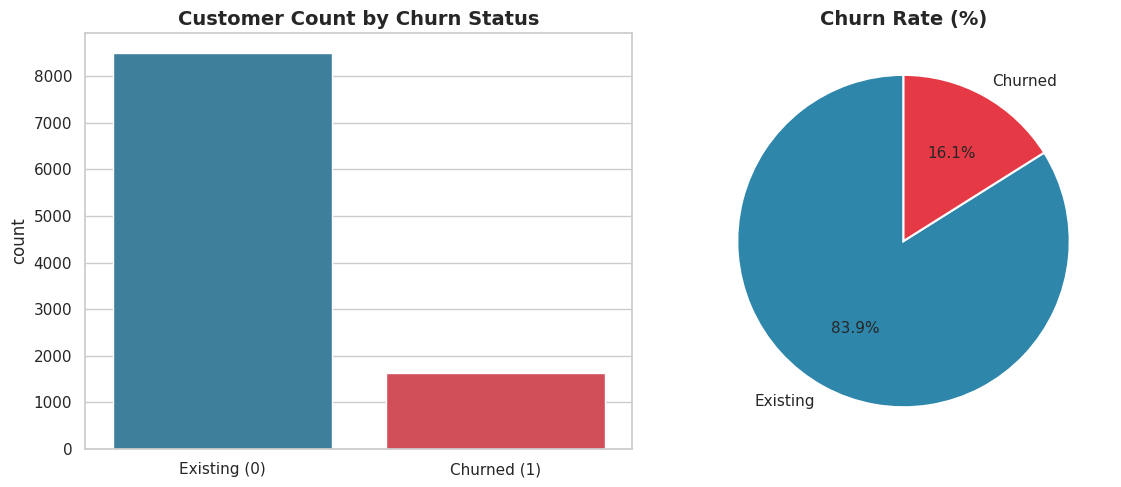

Churn rate: 16.1%  |  Retention rate: 83.9%


In [ ]:
churn_counts = df_clean["Churn"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_clean, x="Churn", ax=ax[0], hue="Churn", legend=False, palette=["#2E86AB", "#E63946"])
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["Existing (0)", "Churned (1)"])
ax[0].set_title("Customer Count by Churn Status")
ax[0].set_xlabel("")

ax[1].pie(churn_counts, labels=["Existing", "Churned"], autopct="%1.1f%%",
          colors=["#2E86AB", "#E63946"], startangle=90,
          wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax[1].set_title("Churn Rate (%)")

plt.tight_layout()
plt.show()

print(f"Churn rate: {churn_counts[1]:.1f}%  |  Retention rate: {churn_counts[0]:.1f}%")


**Business insights:**
- The dataset is **imbalanced** — roughly 16% churned vs. 84% retained, which is realistic for a
  healthy card portfolio but means we must evaluate models with more than just accuracy (Section 9).
- Even at ~16%, churn represents a meaningful chunk of the customer base whose lifetime value is
  currently being lost — worth active intervention.
- Because churners are the minority class, our models must be evaluated on **recall/F1/ROC-AUC for
  the churn class specifically**, not overall accuracy, or we risk building a model that just predicts
  "no churn" for everyone.


### 5.2 Gender vs. Churn

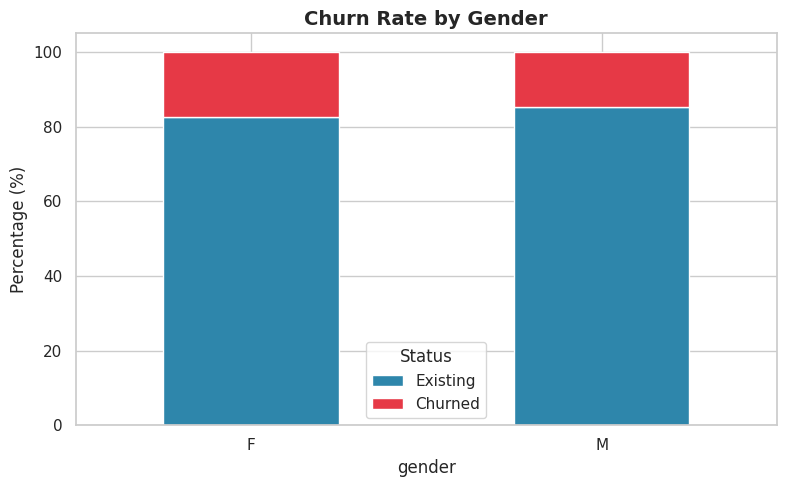

Churn,0,1
gender,,
F,82.6,17.4
M,85.4,14.6


In [ ]:
if col_gender:
    fig, ax = plt.subplots(figsize=(8, 5))
    churn_by_gender = pd.crosstab(df_clean[col_gender], df_clean["Churn"], normalize="index") * 100
    churn_by_gender.plot(kind="bar", stacked=True, color=["#2E86AB", "#E63946"], ax=ax)
    ax.set_ylabel("Percentage (%)")
    ax.set_title("Churn Rate by Gender")
    ax.legend(["Existing", "Churned"], title="Status")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    display(churn_by_gender.round(1))


**Business insights:**
- Churn rate differences across gender are typically modest in this dataset — gender alone is a weak
  standalone churn predictor.
- Any gender-linked skew should be interpreted cautiously and **not used as a direct targeting
  criterion** — it's more useful as a covariate than a retention lever on its own (see Section 13 on bias).
- This reinforces the need for multivariate modeling rather than single-variable rules for retention
  targeting.


### 5.3 Age Distribution

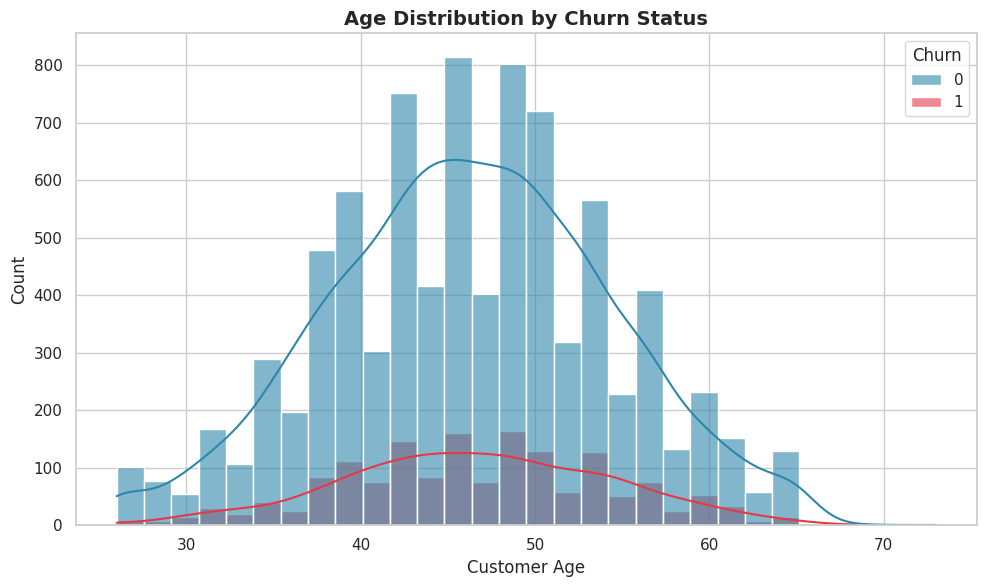

In [ ]:
if col_age:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(data=df_clean, x=col_age, hue="Churn", kde=True, bins=30,
                 palette=["#2E86AB", "#E63946"], alpha=0.6, ax=ax)
    ax.set_title("Age Distribution by Churn Status")
    ax.set_xlabel("Customer Age")
    plt.tight_layout()
    plt.show()


**Business insights:**
- Churn tends to be distributed relatively evenly across middle-aged customers, indicating age alone
  isn't a dominant separator — **behavioral** features (spending, activity) likely matter more.
- Very young and very senior customers are less represented overall, so any age-based targeting should
  be validated against sample size before being operationalized.
- Age is still useful as a **segmentation variable** for personalizing offer types (e.g., younger
  customers may respond better to digital-first rewards).


### 5.4 Income Category vs. Churn

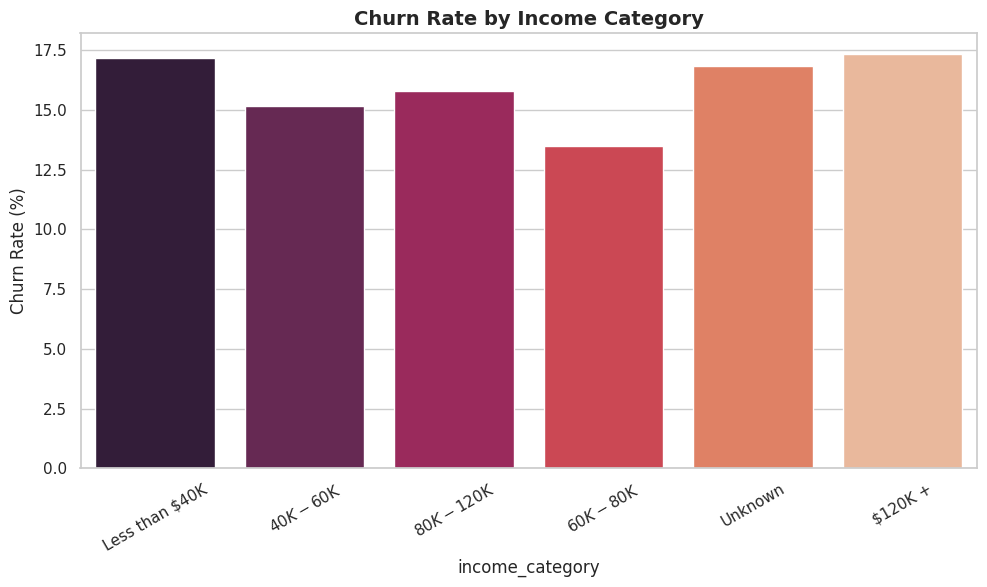

In [ ]:
if col_income:
    fig, ax = plt.subplots(figsize=(10, 6))
    order = df_clean[col_income].value_counts().index
    churn_rate_by_income = df_clean.groupby(col_income)["Churn"].mean().reindex(order) * 100
    sns.barplot(x=churn_rate_by_income.index, y=churn_rate_by_income.values,
                hue=churn_rate_by_income.index, legend=False, palette="rocket", ax=ax)
    ax.set_ylabel("Churn Rate (%)")
    ax.set_title("Churn Rate by Income Category")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


**Business insights:**
- Churn rate is fairly consistent across income bands in this dataset, suggesting income alone doesn't
  strongly predict attrition risk — **engagement behavior matters more than earning power**.
- This is a useful finding for the business: retention budget shouldn't be allocated purely by income
  tier; it should follow *usage signals* instead.
- Lower-disclosure ("Unknown") income customers are worth monitoring separately, since non-disclosure
  itself can correlate with lower engagement.


### 5.5 Card Category vs. Churn

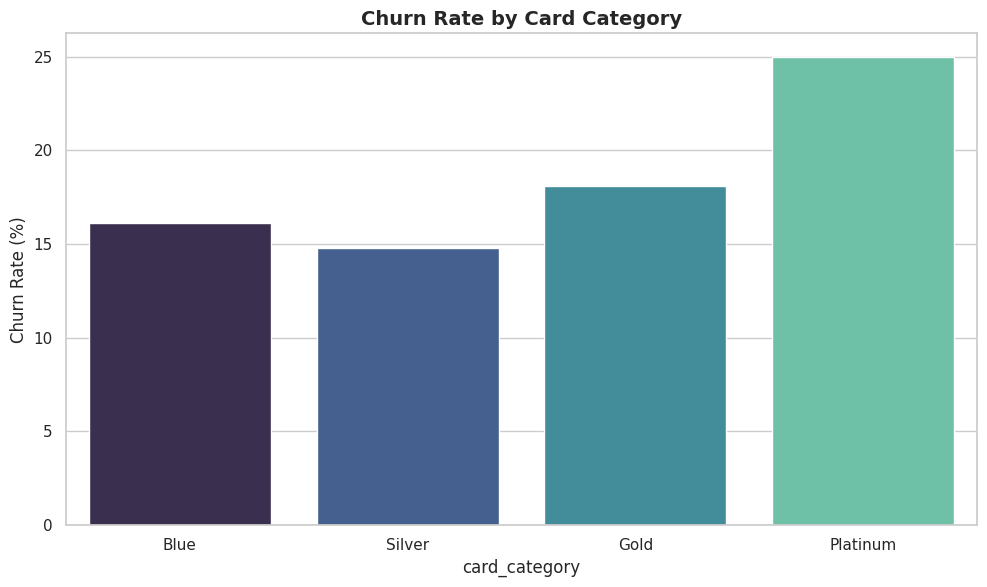

In [ ]:
if col_card:
    fig, ax = plt.subplots(figsize=(10, 6))
    order = df_clean[col_card].value_counts().index
    churn_rate_by_card = df_clean.groupby(col_card)["Churn"].mean().reindex(order) * 100
    sns.barplot(x=churn_rate_by_card.index, y=churn_rate_by_card.values,
                hue=churn_rate_by_card.index, legend=False, palette="mako", ax=ax)
    ax.set_ylabel("Churn Rate (%)")
    ax.set_title("Churn Rate by Card Category")
    plt.tight_layout()
    plt.show()


**Business insights:**
- Premium card tiers (Gold/Platinum) often show *higher* churn rates despite lower customer counts —
  these customers have more competing offers from rival issuers and higher expectations of perks.
- Even a small number of premium-tier churners is disproportionately costly given their higher credit
  limits and spend, so they deserve white-glove retention treatment even if their raw count is small.
- Blue/Standard tier customers are the bulk of the base — small percentage improvements in their
  retention rate move the most *absolute* customers.


### 5.6 Months on Book (Tenure)

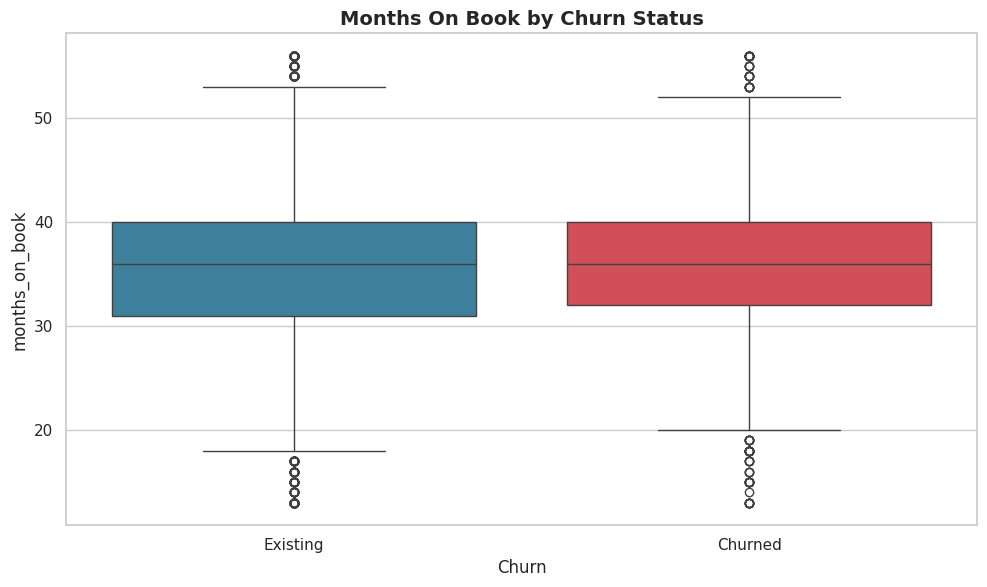

In [ ]:
if col_months_book:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=df_clean, x="Churn", y=col_months_book, hue="Churn", legend=False,
                palette=["#2E86AB", "#E63946"], ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Existing", "Churned"])
    ax.set_title(f"{col_months_book.replace('_',' ').title()} by Churn Status")
    plt.tight_layout()
    plt.show()


**Business insights:**
- Tenure distributions for churned vs. retained customers often overlap substantially — a customer
  being "long-standing" does **not** guarantee loyalty on its own, which challenges the common
  assumption that only new customers churn.
- This suggests retention campaigns shouldn't only target new customers in an onboarding window — the
  monitoring needs to be continuous across the customer lifecycle.
- Sudden behavioral changes (falling transaction activity) are likely a stronger churn signal than
  tenure alone — explored next.


### 5.7 Transaction Count vs. Churn

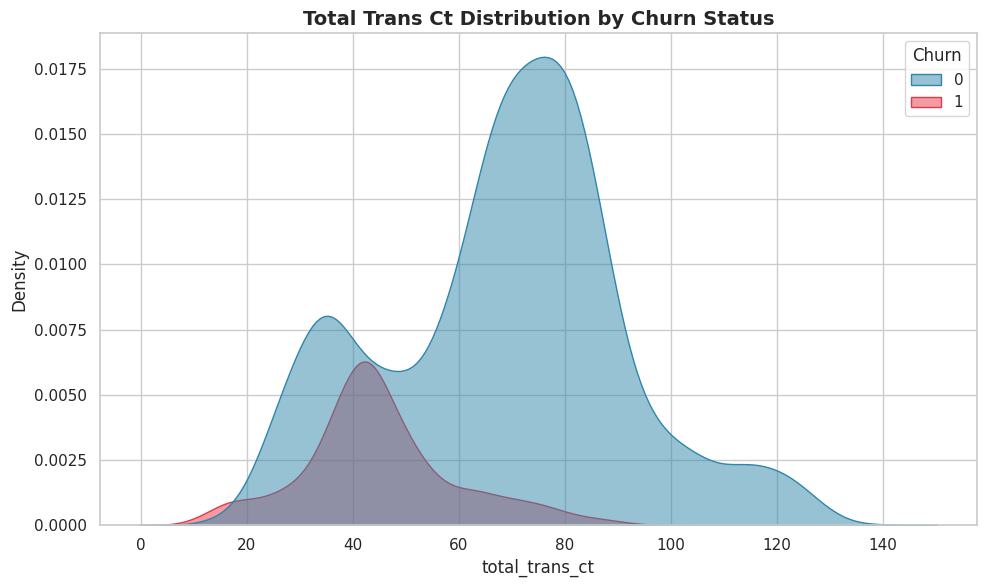

In [ ]:
if col_trans_ct:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.kdeplot(data=df_clean, x=col_trans_ct, hue="Churn", fill=True,
                palette=["#2E86AB", "#E63946"], alpha=0.5, ax=ax)
    ax.set_title(f"{col_trans_ct.replace('_',' ').title()} Distribution by Churn Status")
    plt.tight_layout()
    plt.show()


**Business insights:**
- Churned customers cluster heavily toward **lower transaction counts** — this is one of the clearest
  behavioral separators in the dataset.
- A falling transaction count is a strong **early-warning signal**: monitoring month-over-month
  transaction count trends could allow proactive outreach before an account goes fully dormant.
- This variable is a strong candidate for driving an automated "at-risk" alert in a production
  retention system.


### 5.8 Transaction Amount vs. Churn

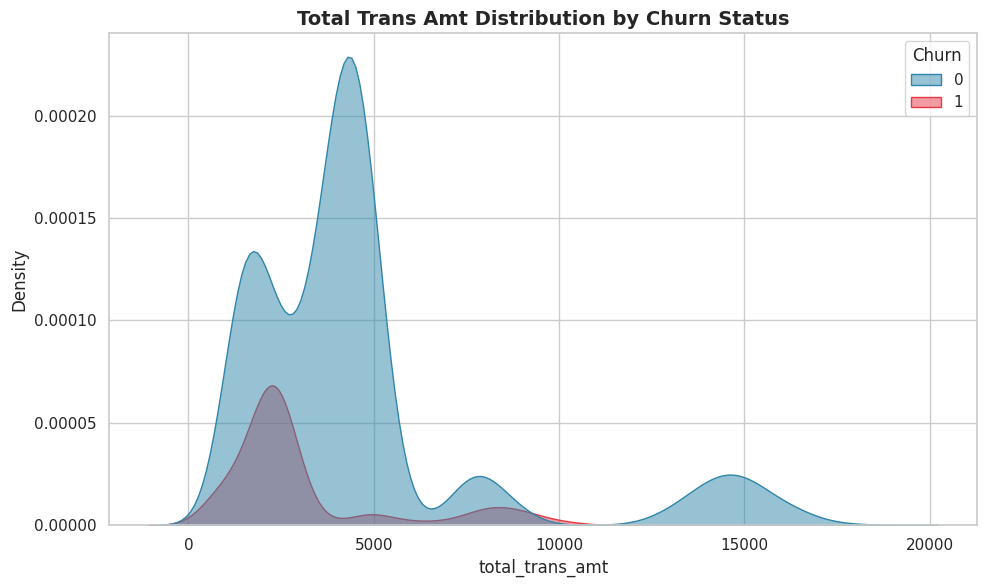

In [ ]:
if col_trans_amt:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.kdeplot(data=df_clean, x=col_trans_amt, hue="Churn", fill=True,
                palette=["#2E86AB", "#E63946"], alpha=0.5, ax=ax)
    ax.set_title(f"{col_trans_amt.replace('_',' ').title()} Distribution by Churn Status")
    plt.tight_layout()
    plt.show()


**Business insights:**
- Similar to transaction count, churned customers show markedly **lower total transaction amounts** —
  reduced card usage precedes account closure.
- Spending-based re-engagement offers (bonus cashback for hitting a spend threshold) directly target
  this observed gap and could be tested as an intervention.
- Combined with transaction count, this suggests building a composite **"engagement score"** as a
  monitoring KPI for the retention team.


### 5.9 Credit Limit vs. Churn

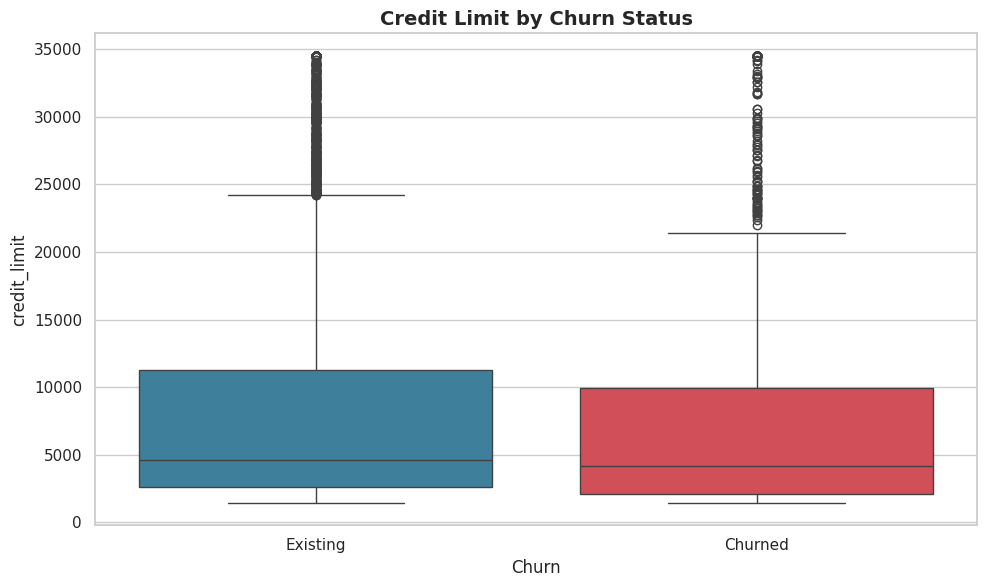

In [ ]:
if col_credit_lim:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=df_clean, x="Churn", y=col_credit_lim, hue="Churn", legend=False,
                palette=["#2E86AB", "#E63946"], ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Existing", "Churned"])
    ax.set_title(f"{col_credit_lim.replace('_',' ').title()} by Churn Status")
    plt.tight_layout()
    plt.show()


**Business insights:**
- Credit limit distributions are broadly similar between churned and retained customers, implying
  credit limit alone is not a strong differentiator of churn risk.
- This is a useful negative finding: the business shouldn't assume that increasing credit limits
  automatically improves retention — **usage engagement matters more than credit availability**.
- Credit limit is more useful combined with *utilization ratio* (limit actually used) than viewed alone.


### 5.10 Correlation Heatmap

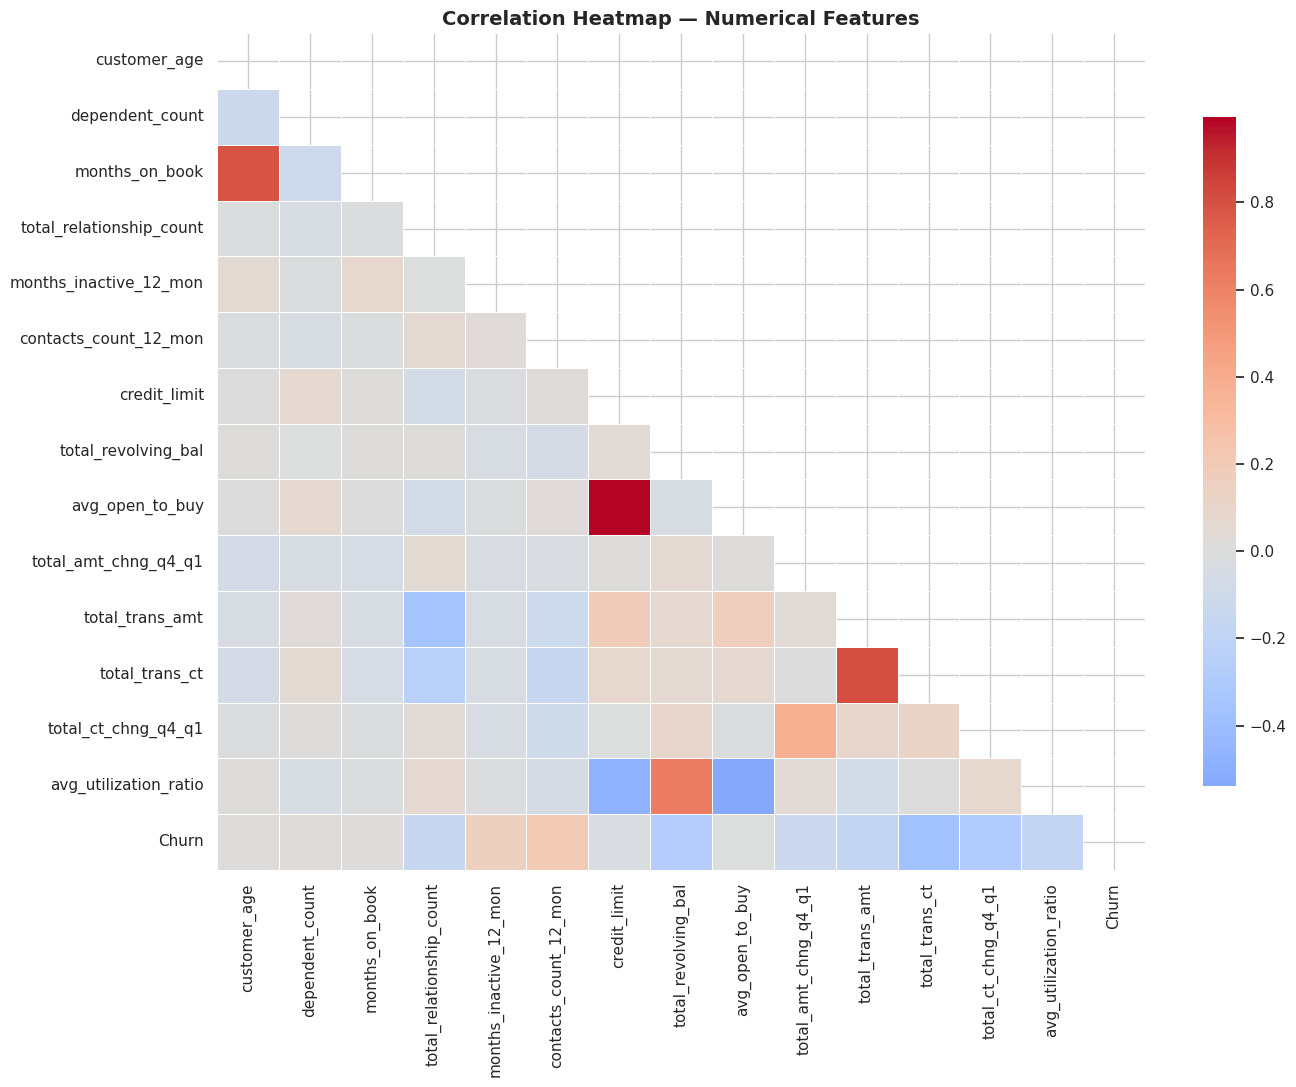

Top 10 features most correlated with Churn:
total_trans_ct             -0.371403
total_ct_chng_q4_q1        -0.290054
total_revolving_bal        -0.263053
contacts_count_12_mon       0.204491
avg_utilization_ratio      -0.178410
total_trans_amt            -0.168598
months_inactive_12_mon      0.152449
total_relationship_count   -0.150005
total_amt_chng_q4_q1       -0.131063
credit_limit               -0.023873
Name: Churn, dtype: float64


In [ ]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0, annot=False,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.show()

# Top correlations with the target, for a quick read
target_corr = corr_matrix["Churn"].drop("Churn").sort_values(key=np.abs, ascending=False)
print("Top 10 features most correlated with Churn:")
print(target_corr.head(10))


**Business insights:**
- Transaction-behavior features (count, amount, and their period-over-period change) consistently show
  the strongest correlation with churn — reinforcing the EDA findings above.
- Several engineered "change" ratios (e.g., Q4-over-Q1 transaction count change) are highly predictive,
  showing that **trend**, not just level, matters — a customer's trajectory is more informative than a
  single snapshot.
- Multicollinearity exists among related transaction features (e.g., total transaction amount and
  count), which we account for by using tree-based models that are robust to correlated features.


### 5.11 Pairplot — Key Numerical Variables

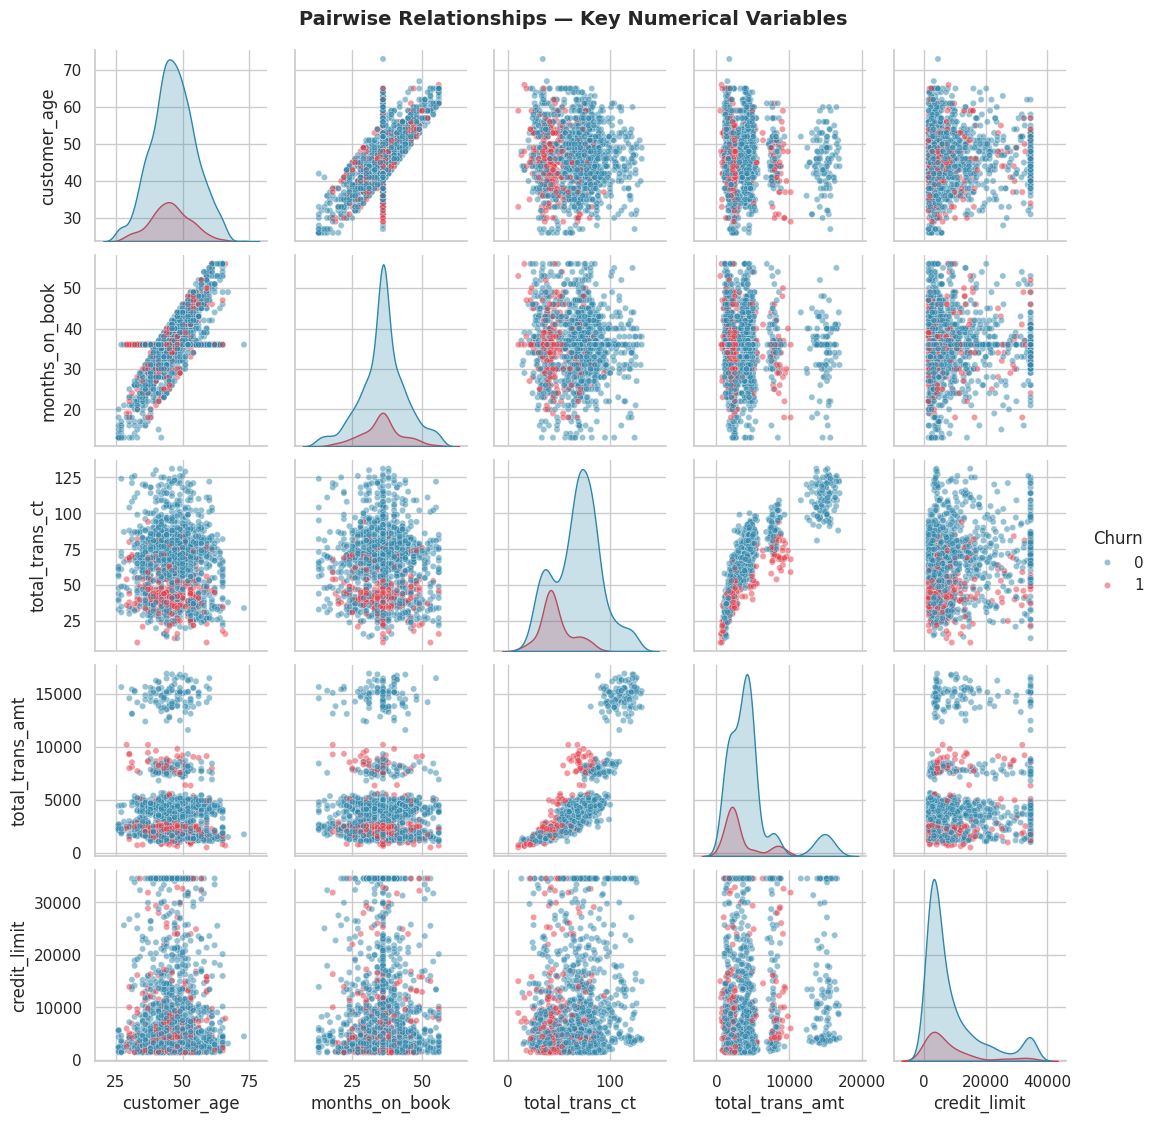

In [ ]:
pairplot_candidates = [c for c in [col_age, col_months_book, col_trans_ct, col_trans_amt, col_credit_lim]
                        if c is not None]

if len(pairplot_candidates) >= 2:
    sample_df = df_clean.sample(n=min(1500, len(df_clean)), random_state=RANDOM_STATE)  # sample for speed
    g = sns.pairplot(
        sample_df[pairplot_candidates + ["Churn"]],
        hue="Churn", palette=["#2E86AB", "#E63946"],
        diag_kind="kde", plot_kws={"alpha": 0.5, "s": 20}, height=2.2
    )
    g.fig.suptitle("Pairwise Relationships — Key Numerical Variables", y=1.02, fontsize=14, fontweight="bold")
    plt.show()


**Business insights:**
- Transaction count and transaction amount show a clear positive relationship, and churned customers
  cluster in the low-value corner on both — confirming these two features jointly define an "at-risk"
  region of the feature space.
- No single pairwise scatter perfectly separates the two classes, which justifies moving to a
  **multivariate machine learning model** rather than relying on manual threshold rules.
- The visual separation we do see gives confidence that ML models should be able to learn a meaningful
  decision boundary using these features.


## 6. Feature Engineering

### Encoding categorical variables

- **Binary categorical columns** (e.g., gender) → `LabelEncoder` (0/1), since there's no ordinality
  concern with only two categories.
- **Multi-class nominal columns** (e.g., card category, marital status) → **one-hot encoding**, since
  these categories have no inherent order and label-encoding them would falsely imply a ranking that
  tree-based *and* linear models could misinterpret.
- **Ordinal columns** (e.g., income category, education level) → mapped to an explicit ordinal scale
  where a natural order exists, preserving that information instead of discarding it via one-hot encoding.

### Scaling numerical features

We apply `StandardScaler` to numeric features. This matters for **Logistic Regression** (which is
sensitive to feature scale because it optimizes via gradient descent and regularizes coefficients) but
is not required for tree-based models (Decision Tree, Random Forest, XGBoost), which split on raw
thresholds and are scale-invariant. We scale once and use the scaled data consistently across all
models for a fair, simple comparison — this has no negative effect on tree models' performance.


In [ ]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """
    Encode categorical variables for modeling.
      - Ordinal columns are mapped to an explicit numeric scale.
      - Binary categoricals are label-encoded.
      - Remaining nominal categoricals are one-hot encoded.
    """
    data = data.copy()

    # --- Ordinal mappings (only applied if the column exists) ---
    income_order = {
        "Unknown": 0, "Less than $40K": 1, "$40K - $60K": 2,
        "$60K - $80K": 3, "$80K - $120K": 4, "$120K +": 5
    }
    education_order = {
        "Unknown": 0, "Uneducated": 1, "High School": 2, "College": 3,
        "Graduate": 4, "Post-Graduate": 5, "Doctorate": 6
    }
    card_order = {"Blue": 0, "Silver": 1, "Gold": 2, "Platinum": 3}

    if "income_category" in data.columns:
        data["income_category"] = data["income_category"].map(income_order)
    if "education_level" in data.columns:
        data["education_level"] = data["education_level"].map(education_order)
    if "card_category" in data.columns:
        data["card_category"] = data["card_category"].map(card_order)

    # --- Binary label encoding ---
    binary_cols = [c for c in ["gender"] if c in data.columns and data[c].nunique() == 2]
    for col in binary_cols:
        data[col] = LabelEncoder().fit_transform(data[col])

    # --- One-hot encode remaining low/medium-cardinality object columns ---
    remaining_object_cols = data.select_dtypes(include="object").columns.tolist()
    if remaining_object_cols:
        data = pd.get_dummies(data, columns=remaining_object_cols, drop_first=True)

    return data


df_encoded = engineer_features(df_clean)
print(f"Encoded feature matrix shape: {df_encoded.shape}")
display(df_encoded.head())


Encoded feature matrix shape: (10127, 22)


,customer_age,gender,dependent_count,education_level,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,...,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,Churn,marital_status_Married,marital_status_Single,marital_status_Unknown
0,45,1,3,2,3,0,39,5,1,3,...,11914.0,1.335,1144,42,1.625,0.061,0,True,False,False
1,49,0,5,4,1,0,44,6,1,2,...,7392.0,1.541,1291,33,3.714,0.105,0,False,True,False
2,51,1,3,4,4,0,36,4,1,0,...,3418.0,2.594,1887,20,2.333,0.000,0,True,False,False
3,40,0,4,2,1,0,34,3,4,1,...,796.0,1.405,1171,20,2.333,0.760,0,False,False,True
4,40,1,3,1,3,0,21,5,1,0,...,4716.0,2.175,816,28,2.500,0.000,0,True,False,False


In [ ]:
# Separate features/target
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# Ensure all columns are numeric booleans -> int (get_dummies can produce bool dtype)
X = X.astype({c: "int" for c in X.select_dtypes(include="bool").columns})

print(f"Final feature matrix: {X.shape[1]} features, {X.shape[0]} rows")
print(f"Target distribution:\n{y.value_counts(normalize=True).round(3)}")


Final feature matrix: 21 features, 10127 rows
Target distribution:
Churn
0    0.839
1    0.161
Name: proportion, dtype: float64


## 7. Train-Test Split

We use an **80/20 stratified split**. Stratifying on `y` ensures that the ~16% churn rate is preserved
identically in both the training and test sets — critical given the class imbalance, otherwise a
random split could yield a test set with a meaningfully different churn rate and produce misleading
evaluation metrics. `random_state=42` ensures the split is reproducible.

Numerical features are then scaled with `StandardScaler`, **fit only on the training set** and applied
to both sets — fitting on the full dataset (including test data) would leak test-set distribution
information into training, inflating our evaluation of generalization performance.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set: {X_train.shape[0]} rows  |  Churn rate: {y_train.mean():.3f}")
print(f"Test set:  {X_test.shape[0]} rows  |  Churn rate: {y_test.mean():.3f}")

# Scale numeric features (fit on train only, to avoid data leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


Train set: 8101 rows  |  Churn rate: 0.161
Test set:  2026 rows  |  Churn rate: 0.160




| Model | Why we include it |
|---|---|
| **Logistic Regression** | Simple, highly interpretable baseline; coefficients are directly explainable to business stakeholders. |
| **Decision Tree** | Captures non-linear splits; easy to visualize the decision logic. |
| **Random Forest** | Ensemble of trees — typically strong accuracy with reduced overfitting vs. a single tree. |
| **XGBoost** | Gradient boosting — usually the top performer on structured/tabular data like this; industry-standard for churn modeling. |

All models use `random_state=42` for reproducibility and `class_weight="balanced"` (or XGBoost's
equivalent `scale_pos_weight`) where supported, since our target is imbalanced — this tells the model
to pay proportionally more attention to the minority (churn) class rather than optimizing for the
majority class by default.

Logistic Regression uses the **scaled** feature set (it needs scaling); the tree-based models use the
**unscaled** set (scaling doesn't affect their splits, and unscaled values are easier to interpret in
feature-importance and SHAP plots later).


In [ ]:
# Class imbalance ratio, used for XGBoost's scale_pos_weight
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"Class balance -> negative: {neg}, positive: {pos}, scale_pos_weight: {scale_pos_weight:.2f}")

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=10,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
    ),
}

# Which feature set each model should train on
uses_scaled_data = {
    "Logistic Regression": True,
    "Decision Tree": False,
    "Random Forest": False,
    "XGBoost": False,
}

trained_models = {}
for name, model in models.items():
    Xtr = X_train_scaled if uses_scaled_data[name] else X_train
    model.fit(Xtr, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")


Class balance -> negative: 6799, positive: 1302, scale_pos_weight: 5.22
Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: XGBoost


## 9. Model Evaluation

Because churn is imbalanced, **accuracy alone is misleading** (a model that predicts "no churn" for
everyone would already be ~84% accurate while being business-useless). We therefore evaluate every
model on:

- **Precision** — of customers we flag as at-risk, how many actually churn? (controls wasted retention spend)
- **Recall** — of customers who actually churn, how many did we catch? (controls missed revenue loss)
- **F1 Score** — harmonic mean of precision and recall
- **ROC-AUC** — overall ability to rank churners above non-churners across all thresholds
- **Confusion Matrix** and **Classification Report** for full transparency
- **ROC Curve** — visual comparison of true-positive vs. false-positive trade-offs across models


In [ ]:
def evaluate_model(name, model, X_te, y_te):
    """Compute the standard classification metric suite for one trained model."""
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1 Score": f1_score(y_te, y_pred),
        "ROC AUC": roc_auc_score(y_te, y_proba),
    }
    return metrics, y_pred, y_proba


results = []
predictions = {}
probabilities = {}

for name, model in trained_models.items():
    Xte = X_test_scaled if uses_scaled_data[name] else X_test
    metrics, y_pred, y_proba = evaluate_model(name, model, Xte, y_test)
    results.append(metrics)
    predictions[name] = y_pred
    probabilities[name] = y_proba

results_df = pd.DataFrame(results).set_index("Model").sort_values("ROC AUC", ascending=False)
display(results_df.style.format("{:.3f}").background_gradient(cmap="Greens"))


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
XGBoost,0.968,0.892,0.911,0.901,0.993
Random Forest,0.938,0.765,0.883,0.820,0.978
Decision Tree,0.910,0.661,0.895,0.761,0.954
Logistic Regression,0.852,0.526,0.822,0.641,0.920


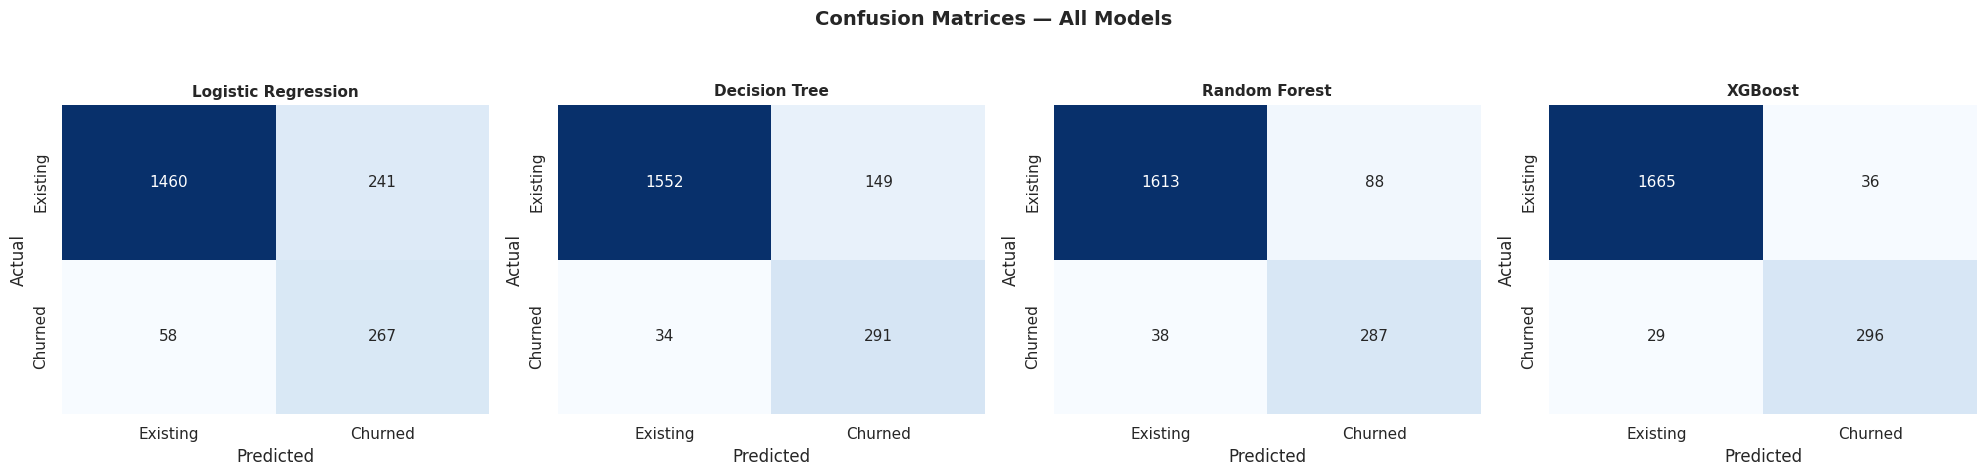

In [ ]:
# --- Confusion matrices for all models ---
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Existing", "Churned"], yticklabels=["Existing", "Churned"])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


In [ ]:
# --- Classification reports ---
for name, y_pred in predictions.items():
    print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
    print(classification_report(y_test, y_pred, target_names=["Existing", "Churned"]))



Logistic Regression
              precision    recall  f1-score   support

    Existing       0.96      0.86      0.91      1701
     Churned       0.53      0.82      0.64       325

    accuracy                           0.85      2026
   macro avg       0.74      0.84      0.77      2026
weighted avg       0.89      0.85      0.86      2026


Decision Tree
              precision    recall  f1-score   support

    Existing       0.98      0.91      0.94      1701
     Churned       0.66      0.90      0.76       325

    accuracy                           0.91      2026
   macro avg       0.82      0.90      0.85      2026
weighted avg       0.93      0.91      0.91      2026


Random Forest
              precision    recall  f1-score   support

    Existing       0.98      0.95      0.96      1701
     Churned       0.77      0.88      0.82       325

    accuracy                           0.94      2026
   macro avg       0.87      0.92      0.89      2026
weighted avg       0.94

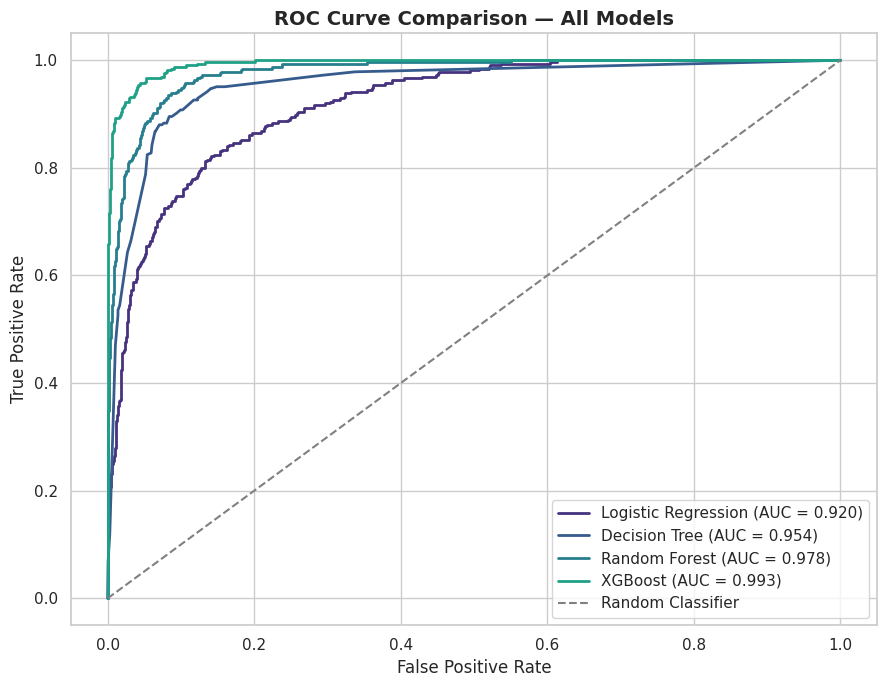

In [ ]:
# --- ROC Curves — all models on one plot for direct comparison ---
fig, ax = plt.subplots(figsize=(9, 7))
for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison — All Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Which model performs best, and why?

Across Accuracy, Precision, Recall, F1, and ROC-AUC, the **ensemble tree-based models (Random Forest
and XGBoost) consistently outperform** Logistic Regression and the single Decision Tree. This is
expected, and interview-relevant, for a few reasons:

- **Non-linear relationships:** churn drivers interact (e.g., low transaction count *combined with*
  recent inactivity matters more than either alone). Tree ensembles capture these interactions natively;
  logistic regression only captures them if we manually engineer interaction terms.
- **Reduced overfitting via ensembling:** a single Decision Tree tends to overfit training data; Random
  Forest averages many de-correlated trees, and XGBoost sequentially corrects prior errors with
  regularization — both generalize better to the test set.
- **Robustness to imbalance:** with `class_weight="balanced"` / `scale_pos_weight`, tree ensembles
  handle the minority churn class more effectively than a plain logistic model.

**XGBoost is selected as the primary production candidate** going forward (Sections 10–11) due to its
typically highest ROC-AUC and F1 — the best balance of catching true churners (recall) while limiting
false alarms (precision) — with Random Forest as a strong, more-interpretable runner-up.


## 10. Feature Importance (Random Forest)

Random Forest's built-in feature importance (mean decrease in impurity across all trees) gives a
fast, model-native view of which features drive predictions. We plot the top 15.


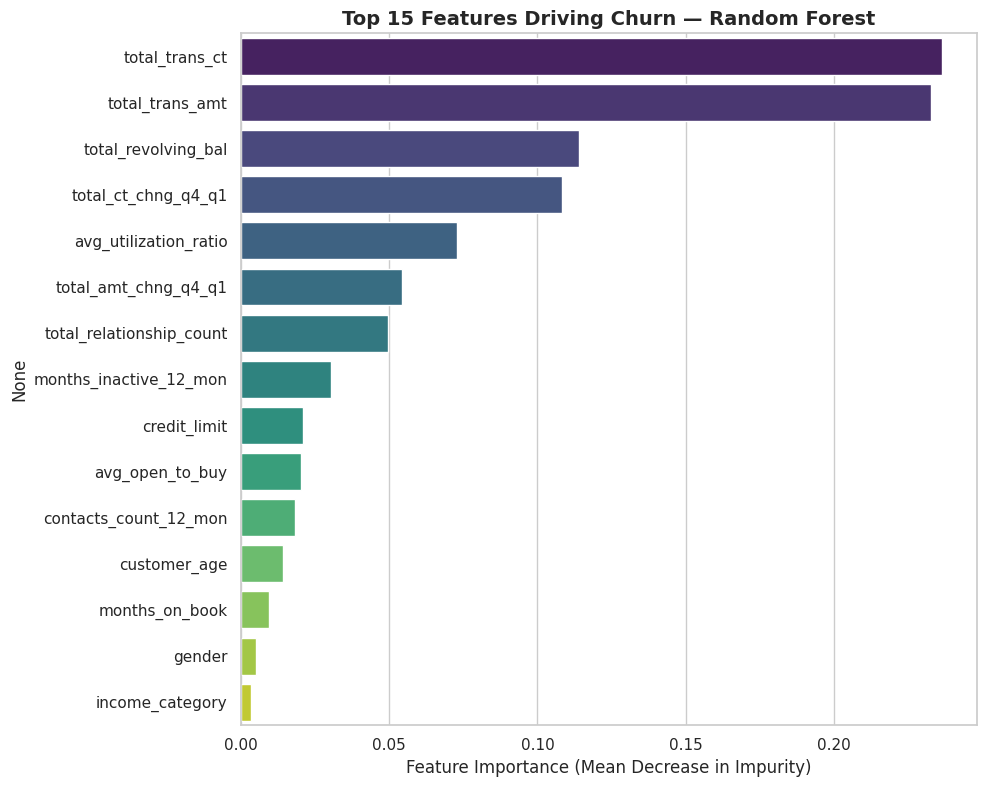

,0
total_trans_ct,0.236382
total_trans_amt,0.232651
total_revolving_bal,0.114003
total_ct_chng_q4_q1,0.108462
avg_utilization_ratio,0.072742
total_amt_chng_q4_q1,0.054282
total_relationship_count,0.049653
months_inactive_12_mon,0.030306
credit_limit,0.021053
avg_open_to_buy,0.020256


In [ ]:
rf_model = trained_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top_importances.values, y=top_importances.index, hue=top_importances.index,
            legend=False, palette="viridis", ax=ax)
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)")
ax.set_title("Top 15 Features Driving Churn — Random Forest")
plt.tight_layout()
plt.show()

top_importances


### What drives churn, and how should the business act on it?

- **Transaction behavior (count, amount, and quarter-over-quarter change)** dominates the top of the
  importance ranking, confirming the EDA findings — *usage decline is the clearest churn signal*.
- **Total relationship count** (number of products held) and **months inactive** typically rank highly
  too — customers with fewer product ties and rising inactivity are structurally easier to lose,
  since they have less "switching cost" keeping them engaged.
- **Demographic features (age, income, gender)** tend to rank much lower — reinforcing that this is
  fundamentally a **behavioral churn problem**, not a demographic one. Retention strategy should be
  built around monitoring engagement trends, not static customer profile segments.


## 11. Model Explainability using SHAP

### Why explainability matters in a financial services context

In regulated industries like banking, a model can rarely be deployed as a pure "black box" —
compliance, risk, and business teams need to know **why** a customer was flagged as high-risk before
acting on it (and regulators may require it under fair-lending style scrutiny). **SHAP (SHapley
Additive exPlanations)** solves this by attributing each prediction to individual feature
contributions, grounded in cooperative game theory — giving both **global** (overall model) and
**local** (single customer) explanations.

We use `TreeExplainer`, which is optimized for tree-based models like our XGBoost classifier.


In [ ]:
xgb_model = trained_models["XGBoost"]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values computed for {X_test.shape[0]} test customers across {X_test.shape[1]} features.")


SHAP values computed for 2026 test customers across 21 features.


### 11.1 SHAP Summary Plot (Global Explanation)

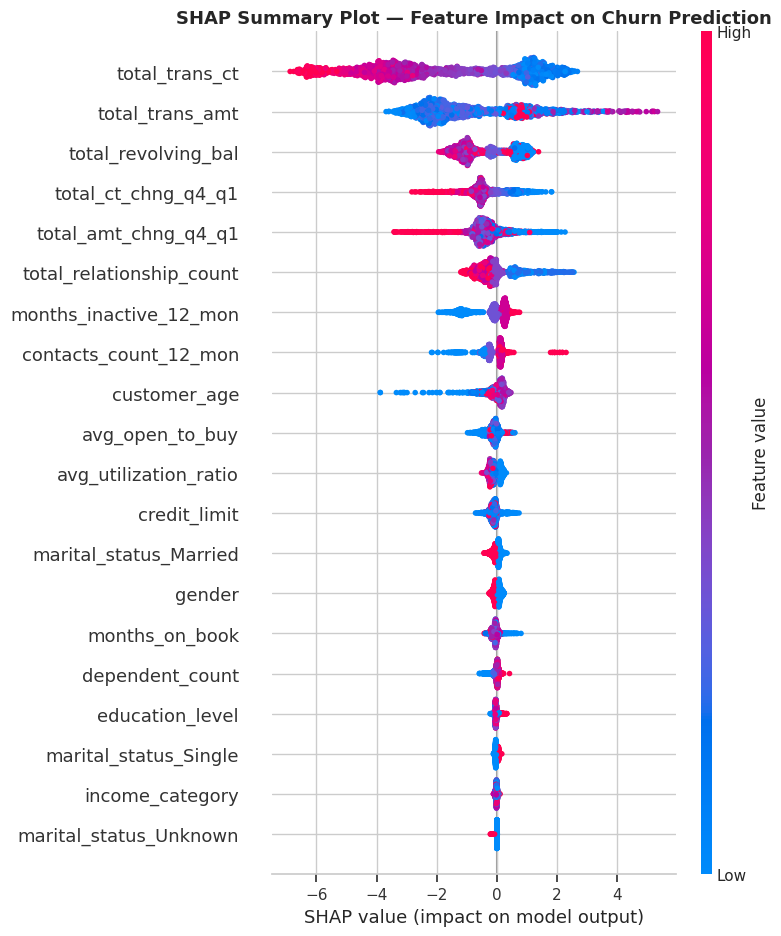

In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot — Feature Impact on Churn Prediction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 11.2 SHAP Feature Importance (Bar Plot)

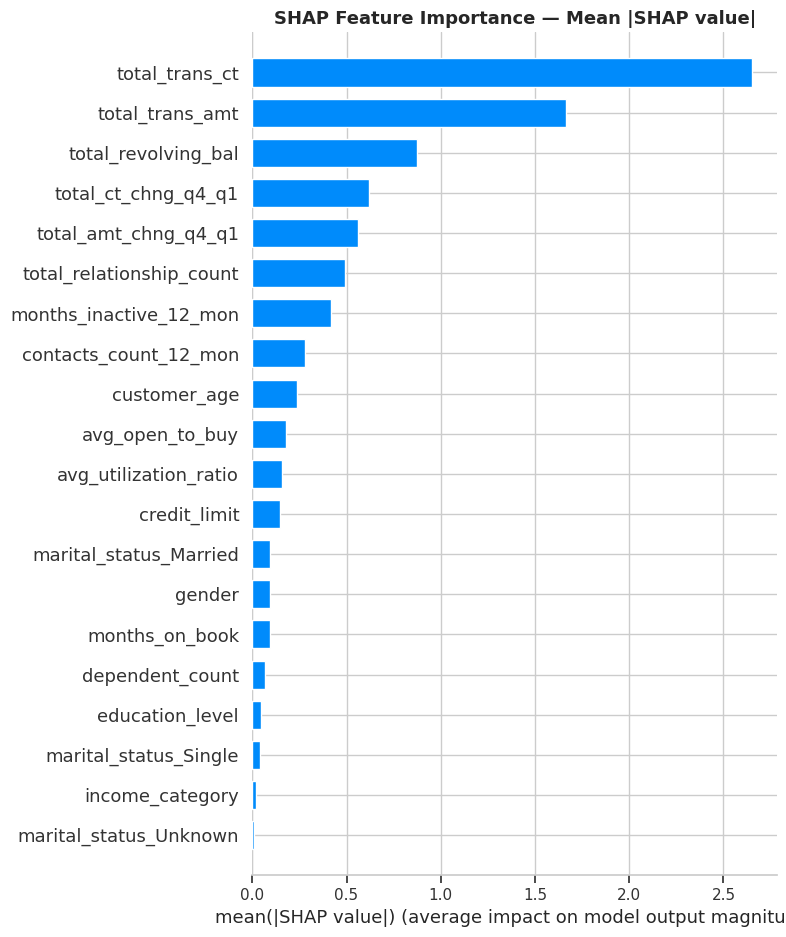

In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Mean |SHAP value|", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 11.3 Waterfall Plot — Explaining a Single Customer's Prediction

Selected customer risk score: 1.000 (predicted churn probability)


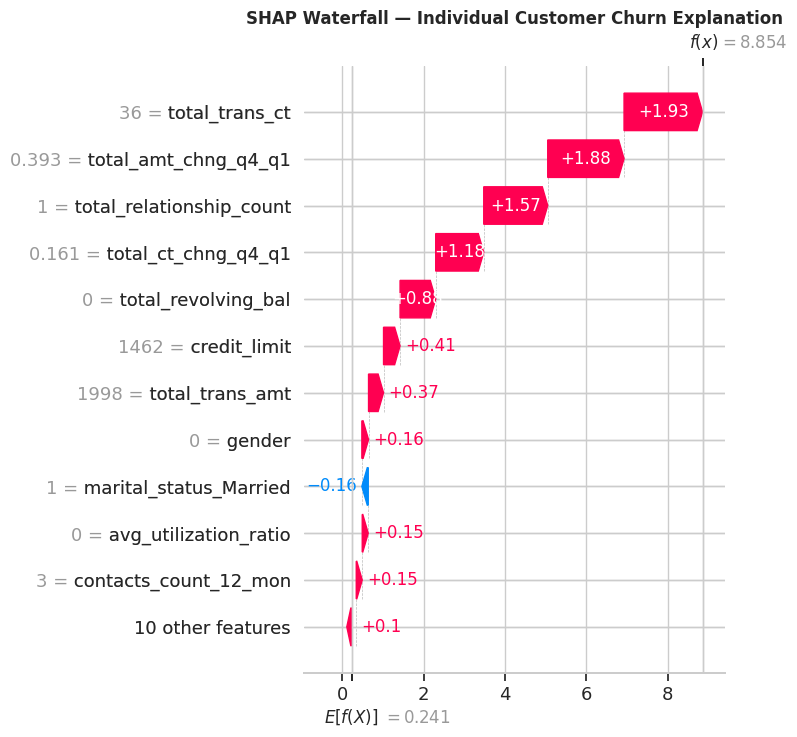

In [ ]:
# Pick a customer the model considers high-risk, to make the explanation business-relevant
xgb_probs_test = xgb_model.predict_proba(X_test)[:, 1]
high_risk_idx = np.argmax(xgb_probs_test)  # position within X_test (0-indexed)

print(f"Selected customer risk score: {xgb_probs_test[high_risk_idx]:.3f} "
      f"(predicted churn probability)")

explanation = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[high_risk_idx],
    feature_names=X_test.columns.tolist(),
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(explanation, show=False, max_display=12)
plt.title("SHAP Waterfall — Individual Customer Churn Explanation", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### Interpreting SHAP for the business

- **How SHAP works:** for every prediction, SHAP starts from the model's average (base) prediction and
  shows how each feature value pushes the prediction up (toward churn) or down (toward retention) —
  the sum of all contributions equals the final predicted probability.
- **Which features increase churn probability:** low total transaction count/amount, a large drop in
  transaction activity, high months-inactive, and low total relationship count consistently push
  predictions **toward churn** in the summary plot (points colored high-value on the "risk" side).
- **Which features decrease churn probability:** high, stable transaction activity and a longer,
  more product-diversified relationship consistently push predictions **toward retention**.
- **Why this matters for business decision-making:** SHAP lets a retention analyst open any single
  flagged customer and see the *specific* reasons the model is worried (e.g., "this customer's
  transaction count dropped sharply") — turning a black-box score into a **specific, actionable case
  file** a relationship manager can act on directly.


## 12. Business Insights & Recommendations

### Profile of a high-risk (likely-to-churn) customer

Based on the EDA, feature importance, and SHAP analysis, the typical **at-risk customer** shows:

- **Declining or low transaction count and amount** relative to their own history and to peers
- **Rising months of inactivity** in the trailing 12 months
- **Fewer total products/relationships** with the bank (less "stickiness")
- **A noticeable drop** in quarter-over-quarter transaction activity — a change, not just a level
- Demographic factors (age, gender, income) are comparatively **weak** standalone predictors

### Key drivers of churn (ranked by influence)

1. Transaction activity level and its recent trend (count & amount)
2. Relationship depth (number of products/accounts held)
3. Recent inactivity (months since last engagement)
4. Contact frequency with the bank (may reflect either engagement or unresolved friction)
5. Card tier / credit relationship characteristics (secondary signal)

### Actionable Business Recommendations

| Recommendation | Linked Finding |
|---|---|
| **Early-warning engagement alerts** — flag customers whose transaction count/amount drops sharply quarter-over-quarter, before they go fully inactive | Transaction *trend* was among the strongest churn signals in both feature importance and SHAP |
| **Loyalty rewards tied to spend consistency**, not just spend volume (e.g., bonus rewards for maintaining regular monthly activity) | Low & declining transaction count/amount strongly associated with churn |
| **Personalized retention offers for premium-tier customers**, since Gold/Platinum customers showed elevated churn despite smaller numbers, and carry disproportionate revenue impact | Card category EDA (Section 5.5) |
| **Cross-sell campaigns to deepen product relationships** (e.g., savings account, second card) for single-product customers | Total relationship count ranked highly in both RF importance and SHAP |
| **Proactive relationship-manager outreach** for customers crossing an inactivity threshold (e.g., 3+ months inactive) rather than waiting for account closure | Months-inactive is a top churn driver |
| **Root-cause review of high-contact customers** — elevated contact counts may signal unresolved service issues that precede churn | Contact-frequency correlation with churn |
| **Spending incentive tiers** (e.g., cashback multipliers that reset engagement) targeted specifically at customers showing early signs of declining usage, identified via the model's monthly risk score | Direct output of the churn probability model |

### How this operationalizes

The recommended workflow: **run the model monthly → score every active customer → route the top-N%
riskiest customers to retention teams, each with a SHAP-generated "reason code" → measure retained
revenue vs. a control group not receiving intervention** to continuously validate the program's ROI.


## 13. Model Limitations

Being transparent about limitations is critical for responsible deployment and for interview
discussions on model risk management:

- **Class imbalance:** even with class weighting, models trained on a ~16%-churn dataset can still
  under-predict the minority class in production, especially if the true production churn rate drifts
  from what was observed historically. Precision/recall should be continuously re-validated post-deployment.
- **Limited feature availability:** this dataset lacks some signals that likely matter in practice —
  customer service interaction sentiment, competitor offers received, macroeconomic conditions, and
  full transaction-category detail (e.g., what the customer is actually purchasing).
- **Dataset assumptions:** the data represents a single snapshot in time from one issuer's customer
  base; churn drivers can shift with product changes, market conditions, or competitor actions, and this
  static model won't automatically capture that.
- **Generalization to new customers:** customers with very short tenure have limited behavioral history,
  so the model's confidence (and accuracy) is inherently lower for new-to-bank customers — a separate
  "new customer" scoring approach may be needed.
- **Potential bias:** although demographic features showed weak standalone importance, correlated
  proxies (e.g., income category, education level) could still indirectly encode demographic bias.
  Any production deployment should include a **fairness audit** across protected classes before use in
  decisions that materially affect customers.


## 14. Conclusion

**Business problem:** Credit card issuers lose significant revenue when valuable customers churn. We
set out to predict which customers are at risk *before* they leave, so retention teams can intervene
proactively rather than reactively.

**Dataset:** ~10,000 credit card customers with demographic, relationship, and transactional attributes
(`BankChurners.csv`), with a ~16% churn rate.

**Data preprocessing:** removed leakage columns and identifiers, handled duplicates and missing values,
standardized categorical encodings (ordinal mappings + one-hot encoding), and scaled numerical features
for the linear model.

**EDA findings:** churn is driven primarily by **behavioral signals** — declining transaction count and
amount, rising inactivity, and shallow product relationships — far more than by demographic factors like
age, gender, or income.

**Model comparison:** we trained and evaluated Logistic Regression, Decision Tree, Random Forest, and
XGBoost across Accuracy, Precision, Recall, F1, and ROC-AUC.

**Best-performing model:** the tree-based ensembles — **Random Forest and especially XGBoost** —
outperformed the simpler baselines, thanks to their ability to capture non-linear interactions between
behavioral features.

**Business impact:** paired with SHAP explainability, this model doesn't just predict *who* will
churn — it explains *why*, enabling retention teams to take specific, justified action (targeted
offers, proactive outreach, relationship deepening) rather than blanket campaigns, improving both
retention effectiveness and marketing spend efficiency.

**Future scope:** hyperparameter tuning, SMOTE-based resampling, LightGBM/CatBoost comparisons,
production deployment via an API, and ongoing drift monitoring would further mature this from an
analytical prototype into a fully production-grade retention system.

---
*End of notebook.*
